In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
demand_base = pd.read_csv('europe_demand_2006-2015.csv', parse_dates=['datetime']).set_index('datetime')[['NO03', 'NO11', 'NO15', 'NO18', 'NO30', 'NO34', 'NO38', 'NO42', 'NO46', 'NO50', 'NO54']]

In [3]:
demand_2030 = pd.read_csv('demand_2030(MWh).csv', parse_dates=['datetime']).set_index('datetime')

In [4]:
demand_2050 = pd.read_csv('demand_2050(MWh).csv', parse_dates=['datetime']).set_index('datetime')

In [5]:
def func_yearly_demand(data):
    demand_yearly = []

    for i in range(1951, 2022):
        demand_yearly.append(data[data.index.year == i].sum().sum())
    
    return np.array(demand_yearly)

In [6]:
yearly_demand_base = func_yearly_demand(demand_base)

In [7]:
yearly_demand_2030 = func_yearly_demand(demand_2030)

In [8]:
yearly_demand_2050 = func_yearly_demand(demand_2050)

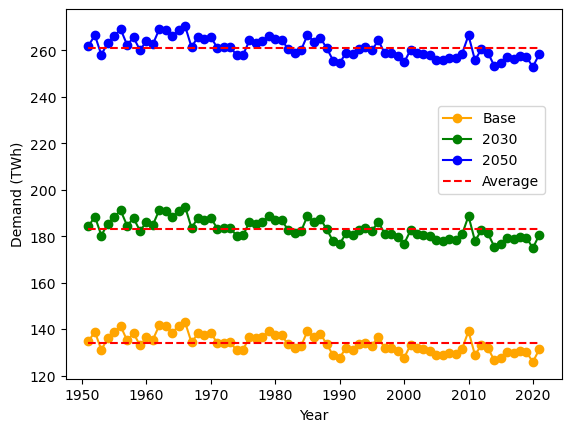

In [9]:
plt.plot(range(1951, 2022), yearly_demand_base/10**6, '-o', color='orange', label='Base')
plt.plot(range(1951, 2022), yearly_demand_2030/10**6, '-o', color='green', label='2030')
plt.plot(range(1951, 2022), yearly_demand_2050/10**6, '-o', color='blue', label='2050')
plt.plot([1951, 2021], [sum(yearly_demand_base/10**6)/len(yearly_demand_base), sum(yearly_demand_base/10**6)/len(yearly_demand_base)], '--', color='red', label='Average')
plt.plot([1951, 2021], [sum(yearly_demand_2030/10**6)/len(yearly_demand_2030), sum(yearly_demand_2030/10**6)/len(yearly_demand_2030)], '--', color='red')
plt.plot([1951, 2021], [sum(yearly_demand_2050/10**6)/len(yearly_demand_2050), sum(yearly_demand_2050/10**6)/len(yearly_demand_2050)], '--', color='red')
plt.legend(loc=(0.75,0.5))
plt.xlabel('Year')
plt.ylabel('Demand (TWh)')
plt.show()

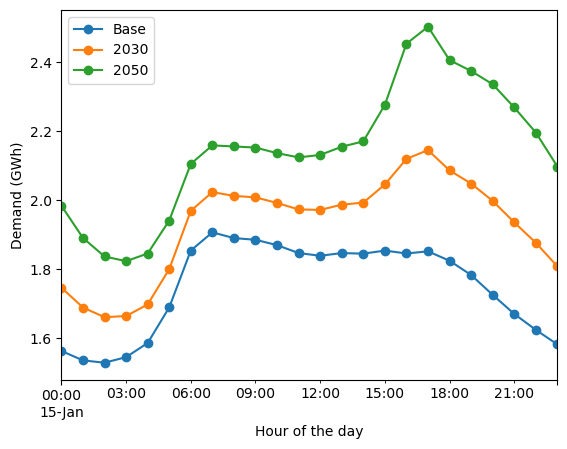

In [10]:
demand_base['NO03']['20210115'].div(10**3).plot(style='-o')
demand_2030['NO03']['20210115'].div(10**3).plot(style='-o')
demand_2050['NO03']['20210115'].div(10**3).plot(style='-o')
plt.legend(['Base', '2030','2050'])
plt.xlabel('Hour of the day')
plt.ylabel('Demand (GWh)')
plt.show()

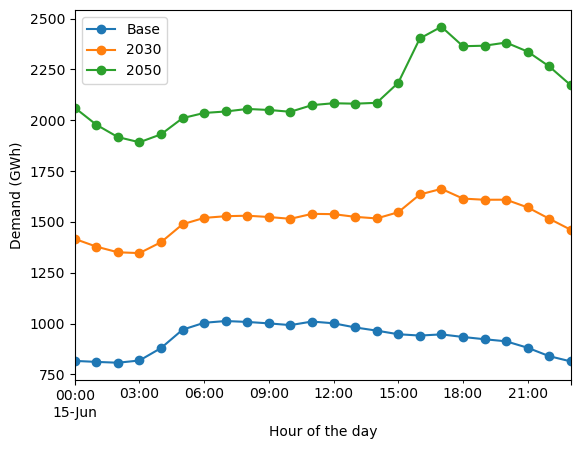

In [11]:
demand_base['NO50']['20210615'].plot(style='-o')
demand_2030['NO50']['20210615'].plot(style='-o')
demand_2050['NO50']['20210615'].plot(style='-o')
plt.legend(['Base', '2030','2050'])
plt.xlabel('Hour of the day')
plt.ylabel('Demand (GWh)')
plt.show()

In [14]:
demand_2030_flatEV = pd.read_csv('demand_2030(flat-EV)(MWh).csv', parse_dates=['datetime']).set_index('datetime')

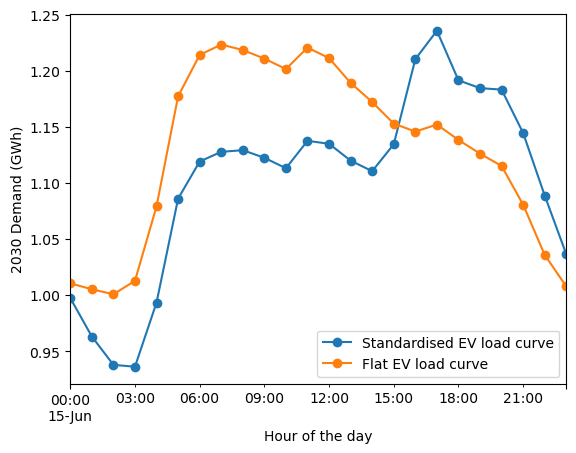

In [15]:
# demand_base['NO50']['20210615'].div(10**3).plot(style='-o', label='Base')
demand_2030['NO03']['20210615'].div(10**3).plot(style='-o', label='Standardised EV load curve')
demand_2030_flatEV['NO03']['20210615'].div(10**3).plot(style='-o', label='Flat EV load curve')
plt.legend()
plt.xlabel('Hour of the day')
plt.ylabel('2030 Demand (GWh)')
# plt.vlines(demand_base['NO50']['20210615'].index, 0, )
# plt.ylim(0.7)
plt.show()

In [16]:
demand_2050_flatEV = pd.read_csv('demand_2050(flat-EV)(MWh).csv', parse_dates=['datetime']).set_index('datetime')

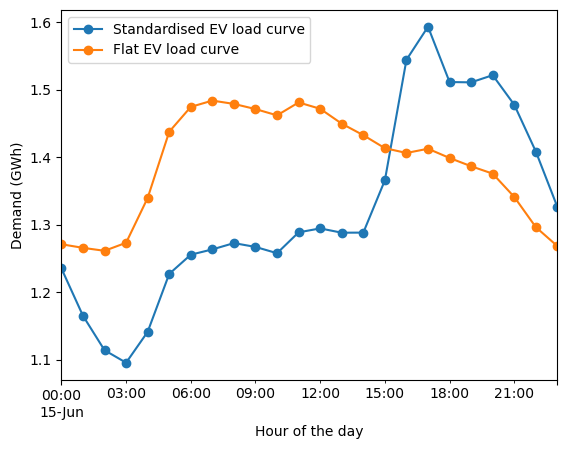

In [119]:
# demand_base['NO50']['20210615'].div(10**3).plot(style='-o', label='Base')
demand_2050['NO03']['20210615'].div(10**3).plot(style='-o', label='Standardised EV load curve')
demand_2050_flatEV['NO03']['20210615'].div(10**3).plot(style='-o', label='Flat EV load curve')
plt.legend()
plt.xlabel('Hour of the day')
plt.ylabel('2050 Demand (GWh)')
plt.show()